In [2]:
from brian2 import *
import numpy as np
from os import listdir
from pathlib import Path
import matplotlib.pyplot as plt
import random as rng
from scipy import constants as constants
defaultclock.dt = 1 * ms
prefs.codegen.target = 'numpy'

INFO       Cache size for target 'cython': 3949122641 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the 'C:\Users\Tansu Celikel\.cython\brian_extensions' directory. [brian2]


In [3]:
def load_data(directory):
    torques = []
    stim_id = []
    for f in listdir(directory):
        torques.append(np.genfromtxt(directory + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    torques = np.asarray(torques)
    return torques, stim_id

In [4]:
def compute_amplitude(torques):
    amplitude = []
    for i in range(len(torques)):
        amplitude.append(np.sqrt(torques[i][1]**2 + torques[i][2]**2))
    return np.asarray(amplitude)

def compute_amplitude_ONOFF(amplitude, th):
    amplitude_ONOFF = np.zeros(len(amplitude))
    th_reached = np.argwhere(amplitude > th)
    amplitude_ONOFF[th_reached[0][0]:th_reached[-1][0]] += 1
    return amplitude_ONOFF

def compute_direction(direction, amplitude):
    direction_array = np.ones(len(amplitude)) * direction
    return direction_array

In [5]:
def DefineFavAngle_nat_oriented(forward_low, forward_high, backward_low, backward_high, nb_neuron):
    forward = [mod(rng.randrange(forward_low, forward_high, 1), 360) for i in range(0, int(nb_neuron/2))]
    backward = [mod(rng.randrange(backward_low, backward_high, 1), 360) for i in range(0, int(nb_neuron/2))]
    fav_angle = np.concatenate((np.asarray(forward), np.asarray(backward)))
    return fav_angle

In [6]:
def DefineFavAngle_nat_oriented_gauss(mu_forward, mu_backward, sigma, nb_neuron):
    forward = [int(mod(rng.gauss(mu_forward, sigma), 360)) for i in range(0, int(nb_neuron/2))]
    backward = [int(mod(rng.gauss(mu_backward, sigma), 360)) for i in range(0, int(nb_neuron/2))]
    fav_angle = np.concatenate((np.asarray(forward), np.asarray(backward)))
    return fav_angle

In [7]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros((duration, 1))
    spike_times = np.round(spike_times/ms)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [8]:
def compute_nb_spike_per_neuron(spike, nb_neuron):
    nb_spike=np.zeros(nb_neuron)
    for i in np.unique(spike.i):
        nb_spike[i] = sum(spike.i == i)
    return nb_spike


In [ ]:
tg = '''
dISRA/dt = (a_null * (v  - El_tg) - ISRA)/tau_SRA_null : amp
Il = Gl_bar * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA + Iapp)/Cm : volt

Iapp : amp
'''

SA1 = '''
Iapp = I(t) * (amplitudeOnOff(t)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA1/dt = (a_SA1 * (v  - El_tg) - ISRA_SA1)/tau_SRA1 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA1 + Iapp + randn() * noiseSA1 * pA)/Cm : volt

fav_direction : 1
noiseSA1 : 1
'''

RA = '''

ampdif = (int(amplitude(t) > amplitude(t-dt)) * (amplitude(t)/amplitude(t-dt))) + (int(amplitude(t-dt) > amplitude(t)) * (amplitude(t-dt)/amplitude(t)))  + int(amplitude(t-dt) == amplitude(t)) : 1
Iapp = I(t) * (amplitudeOnOff(t)) * log(ampdif) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_RA/dt = (a_RA * (v  - El_tg) - ISRA_RA)/tau_RA : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_RA + Iapp + randn() * noiseRA * pA)/Cm : volt

fav_direction : 1
noiseRA : 1
'''

SA2 = '''
Iapp = I(t) * (amplitudeOnOff(t) * amplitude(t)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA2/dt = (a_SA2 * (v  - El_tg) - ISRA_SA2)/tau_SRA2 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA2 + Iapp + randn() * noiseSA2 * pA)/Cm : volt

fav_direction : 1
noiseSA2 : 1
'''

TH_eq = '''
dv/dt = (Iapp - INa - IK - IT - Ih - ILeak - IKleak)/Cm : volt

INa = gNa * m**3 * h * (v - ENa) : amp/meter**2
IK = gK * n**4 * (v - EK) : amp/meter**2
ILeak = gleak * (v - Eleak) : amp/meter**2
IKleak = gKleak * (v - EKleak) : amp/meter**2
IT = gCa * mT_inf**2 * hT * (v - ECa) : amp/meter**2
Ih = gh * (o1 + 2*(1 - c1 - o1)) * (v - Eh) : amp/meter**2

dm/dt = alpha_m * (1 - m) - beta_m * m : 1
dh/dt = alpha_h * (1 - h) - beta_h * h : 1
dn/dt = alpha_n * (1 - n) - beta_n * n : 1
dhT/dt = (hT_inf - hT) / tau_hT : 1

ECa = ((GasConst * 309.15*kelvin) / (2 * FaradConst)) * log(2 / CaBuffer) : volt
CaBufferTemp = ((-10 * IT/(amp/meter**2)) / (2 * FaradConst / (coulomb/mole))) : 1
dCaBuffer/dt = (int(CaBufferTemp > 0) * CaBufferTemp + (0.00024-CaBuffer)/5 ) / ms : 1 

do1/dt = (0.001 * (1 - c1 - o1) - 0.001 * ( (1-p0) / 0.01)) * o1 / ms : 1
dp0/dt = (0.0004 *  (1 - p0) - 0.0004 * ((CaBuffer / 0.002)**4) * p0) / ms : 1
dc1/dt = beta * o1 - alpha * c1 : 1

alpha_m = ((0.32 * (13 - (v/mV + 35))) / (exp((13 - (v/mV + 35))/4) - 1)) / ms : Hz
beta_m = ((0.28 * ((v/mV + 35) - 40)) / (exp(((v/mV + 35) - 40)/5) - 1)) / ms : Hz
alpha_h = (0.128 * exp((17 - v/mV - 35)/18)) / ms : Hz
beta_h = (4 / (1 + exp((40 - v/mV - 35)/5))) / ms : Hz

alpha_n = ((0.032 * (15 - (v/mV + 25))) / (exp((15 - (v/mV + 25))/5) - 1)) / ms : Hz
beta_n = (0.5 * exp((10 - (v/mV + 25)) / 40)) / ms : Hz

alpha = h_inf / tau_s : Hz
beta = (1 - h_inf) / tau_s : Hz

mT_inf = 1 / (1 + exp((-((v/mV + 2) + 57)) / 6.2)) : 1
hT_inf = 1 / (1 + exp(((v/mV + 2) + 81)/4)) : 1
tau_hT = (( 30.8 + (211.4 + exp(((v/mV+2) + 113.2)/5))/(1+exp(((v/mV + 2)+84)/3.2))) / 3.73) * ms : second

h_inf =  1 / (1 + exp( (v/mV + 75)/5.5 )) : 1
tau_s = (20 + 1000 / (exp( (v/mV + 71.5)/14.2 ) + exp( (-(v/mV + 89))/11.6))) * ms: second
    
Cm = 1*uF/cm**2 : farad/meter**2
Iapp : amp/meter**2

taud : second
taur : second
slope : volt

ds1/dt = -s1/taud + 1/2 * (1 + (tanh(v/slope)))* (1-s1)/taur : 1 
'''

#Replace 200 by noiseSA1 or noiseSA2

In [10]:
def model_mechano_noise(fav_direction_SA1, fav_direction_SA2, fav_direction_RA, noiseSA1, noiseSA2, noiseRA):

    El= -50 * mV

    SA1_pop = NeuronGroup(58, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''')
    SA2_pop = NeuronGroup(30, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''')
    RA_pop = NeuronGroup(112, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA + b_RA''')
    TG_pop = NeuronGroup(200, tg, method = 'euler', threshold='v > Vth',
                          reset = '''v = Vreset''')

    BS_pop = NeuronGroup(400, tg, method = 'euler', threshold='v > Vth',
                          reset = '''v = Vreset''')
    
    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S1.connect(i = np.arange(58), j=np.arange(58))
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S2.connect(i = np.arange(30), j=np.arange(58, 88))
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S3.connect(i = np.arange(112), j=np.arange(88, 200))

    S4 = Synapses(TG_pop, BS_pop, model = 'w : volt', on_pre='v += 25*mV')
    S4.connect(p=0.005)
    S5 = Synapses(BS_pop, BS_pop, model = 'w : volt', on_pre='v -= 25*mV')
    S5.connect(condition='i!=j', p=0.005)
    
    
    trace = StateMonitor(SA1_pop, True, record = True)
    spike_SA1 = SpikeMonitor(SA1_pop)
    spike_SA2 = SpikeMonitor(SA2_pop)
    spike_RA = SpikeMonitor(RA_pop)
    spike_TG = SpikeMonitor(TG_pop)
    spike_BS = SpikeMonitor(BS_pop)
    
    SA1_pop.v = El
    SA1_pop.fav_direction = fav_direction_SA1
    SA1_pop.noiseSA1 = noiseSA1
    
    SA2_pop.v = El
    SA2_pop.fav_direction = fav_direction_SA2
    SA2_pop.noiseSA2 = noiseSA2
    
    RA_pop.v = El
    RA_pop.fav_direction = fav_direction_RA
    RA_pop.noiseRA = noiseRA
    
    TG_pop.v = El
    BS_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    model.add(BS_pop)
    
    model.add(S1)
    model.add(S2)
    model.add(S3)
    model.add(S4)
    model.add(S5)
    
    model.add(spike_SA1)
    model.add(spike_SA2)
    model.add(spike_RA)
    model.add(spike_TG)
    model.add(spike_BS)
        
    model.add(trace)

    return model, trace, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS

In [99]:
def model_mechano_TH_CTX(fav_direction_SA1, fav_direction_SA2, fav_direction_RA):

    Eleak = -70*mV 
    spike_detect = -50*mV
    VPM_neuron_num = 70
    L4E_neuron_num = 188
    L4I_neuron_num = 33
    L3E_neuron_num = 158
    L3I_neuron_num = 28
    L2E_neuron_num = 86
    L2I_neuron_num = 15

    ENa_vpm = 50*mV 
    EK_vpm = -100*mV 

    Eh_vpm = -43*mV 
    Eleak_vpm = -70*mV 
    EKleak_vpm = -100*mV

    gNa_vpm = 90*msiemens/cm**2
    gK_vpm = 20*msiemens/cm**2
    gCa_vpm = 2*msiemens/cm**2
    gh_vpm = 0.01*msiemens/cm**2
    gleak_vpm = 0.01*msiemens/cm**2
    gKleak_vpm = 0.0172*msiemens/cm**2

    FaradConst = constants.physical_constants['Faraday constant'][0] * coulomb/mole
    GasConst = constants.gas_constant * joule / (kelvin * mole)

    ########### Constants for CTX/L4 cells ###########

    # Regular-spiking param-values
    RS_gleak     = 1.05e-5      * siemens/cm**2
    RS_Eleak     = -70.3        * mV
    RS_V_T       = -59          * mV
    RS_gNa       = 0.086        * siemens/cm**2
    RS_gK        = 0.006        * siemens/cm**2
    RS_gM        = 15e-5        * siemens/cm**2 
    RS_tau_max_M = 808          * ms

    # Fast-spiking param-values
    FS_diam      = 56.9        * um
    FS_surface   = pi*FS_diam**2

    FS_gleak     = 3.8e-5       * siemens/cm**2
    FS_Eleak     = -70.4        * mV
    FS_gNa       = 0.078        * siemens/cm**2
    FS_V_T       = -58          * mV
    FS_gK        = 0.0039       * siemens/cm**2
    FS_gM        = 5e-5         * siemens/cm**2
    FS_tau_max_M = 602          * ms
        
    # Shared values
  

    El= -50 * mV

    SA1_pop = NeuronGroup(24, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''', dt = 1*ms)
    SA2_pop = NeuronGroup(10, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''', dt = 1*ms)
    RA_pop = NeuronGroup(36, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA''', dt = 1*ms)
    TG_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    BS_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    
    TC_pop = NeuronGroup(VPM_neuron_num, VPM, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method='rk4', dt=0.01*ms)
    TC_pop.v = -65*mV + (10 * np.random.rand(1, VPM_neuron_num) * mV)  # Resting potential

    #TC_pop.m = 0 + np.finfo(float).eps
    #TC_pop.h = 0 + np.finfo(float).eps
    #TC_pop.n = 0 + np.finfo(float).eps
    #TC_pop.hT = 0 + np.finfo(float).eps
    TC_pop.CaBuffer = 0 + np.finfo(float).eps
    #TC_pop.o1 = 0 + np.finfo(float).eps
    #TC_pop.c1 = 0 + np.finfo(float).eps
    #TC_pop.p0 = 0 + np.finfo(float).eps

    L4E_cells = NeuronGroup(L4E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L4E_cells.gleak    =   [RS_gleak]
    L4E_cells.Eleak    =   [RS_Eleak]
    L4E_cells.V_T      =   [RS_V_T]
    L4E_cells.gNa      =   [RS_gNa]
    L4E_cells.gK       =   [RS_gK]
    L4E_cells.gM       =   [RS_gM]
    L4E_cells.tau_max_M =  [RS_tau_max_M]
    L4E_cells.v        =   [-65] * mV

    L4I_cells = NeuronGroup(L4I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L4I_cells.gleak    =   [FS_gleak]
    L4I_cells.Eleak    =   [FS_Eleak]
    L4I_cells.V_T      =   [FS_V_T]
    L4I_cells.gNa      =   [FS_gNa]
    L4I_cells.gK       =   [FS_gK]
    L4I_cells.gM       =   [FS_gM]
    L4I_cells.tau_max_M =  [FS_tau_max_M]
    L4I_cells.v        =   [-65] * mV

    L3E_cells = NeuronGroup(L3E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L3E_cells.gleak    =   [RS_gleak]
    L3E_cells.Eleak    =   [RS_Eleak]
    L3E_cells.V_T      =   [RS_V_T]
    L3E_cells.gNa      =   [RS_gNa]
    L3E_cells.gK       =   [RS_gK]
    L3E_cells.gM       =   [RS_gM]
    L3E_cells.tau_max_M =  [RS_tau_max_M]
    L3E_cells.v        =   [-65] * mV

    L3I_cells = NeuronGroup(L3I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L3I_cells.gleak    =   [FS_gleak]
    L3I_cells.Eleak    =   [FS_Eleak]
    L3I_cells.V_T      =   [FS_V_T]
    L3I_cells.gNa      =   [FS_gNa]
    L3I_cells.gK       =   [FS_gK]
    L3I_cells.gM       =   [FS_gM]
    L3I_cells.tau_max_M =  [FS_tau_max_M]
    L3I_cells.v        =   [-65] * mV

    L2E_cells = NeuronGroup(L2E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L2E_cells.gleak    =   [RS_gleak]
    L2E_cells.Eleak    =   [RS_Eleak]
    L2E_cells.V_T      =   [RS_V_T]
    L2E_cells.gNa      =   [RS_gNa]
    L2E_cells.gK       =   [RS_gK]
    L2E_cells.gM       =   [RS_gM]
    L2E_cells.tau_max_M =  [RS_tau_max_M]
    L2E_cells.v        =   [-65] * mV

    L2I_cells = NeuronGroup(L2I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L2I_cells.gleak    =   [FS_gleak]
    L2I_cells.Eleak    =   [FS_Eleak]
    L2I_cells.V_T      =   [FS_V_T]
    L2I_cells.gNa      =   [FS_gNa]
    L2I_cells.gK       =   [FS_gK]
    L2I_cells.gM       =   [FS_gM]
    L2I_cells.tau_max_M =  [FS_tau_max_M]
    L2I_cells.v        =   [-65] * mV

    # AMPA params
    Esyn_AMPA = 0       * mV  
    gsyn_AMPA = 0.1 * 0.17    * msiemens/cm**2
    slope_AMPA = 10     * mvolt
    taud_AMPA = 2       * ms
    taur_AMPA = 0.1     * ms

    # GABA params
    Esyn_GABA = -80         * mV 
    gsyn_GABA = 0.25 * 0.5   * msiemens/cm**2 
    taud_GABA = 10      * ms
    taur_GABA = 0.2     * ms
    slope_GABA = 10     * mvolt

    VPM_to_L4E = Synapses(TC_pop, L4E_cells, on_pre = 'ampa2_post = 7 * s1_pre', dt= 0.01 *ms)
    VPM_to_L4I = Synapses(TC_pop, L4I_cells, on_pre = 'ampa2_post = 9 * s1_pre', dt= 0.01 *ms)

    L4E_to_L4E = Synapses(L4E_cells, L4E_cells, on_pre = 'ampa2_post = 3.3 * ampa1_pre', dt= 0.01 *ms)
    L4E_to_L4I = Synapses(L4E_cells, L4I_cells, on_pre = 'ampa2_post = 7.9 * ampa1_pre', dt= 0.01 *ms)
    L4I_to_L4E = Synapses(L4I_cells, L4E_cells, on_pre = 'gaba2_post = 16 * gaba1_pre', dt= 0.01 *ms)
    L4I_to_L4I = Synapses(L4I_cells, L4I_cells, on_pre = 'gaba2_post = 14 * gaba1_pre', dt= 0.01 *ms)

    L4E_to_L3E = Synapses(L4E_cells, L3E_cells, on_pre = 'ampa2_post = 2.4 * ampa1_pre', dt= 0.01 *ms)
    L4E_to_L3I = Synapses(L4E_cells, L3I_cells, on_pre = 'ampa2_post = 5.7 * ampa1_pre', dt= 0.01 *ms)
    L4I_to_L3E = Synapses(L4I_cells, L3E_cells, on_pre = 'gaba2_post = 14 * gaba1_pre', dt= 0.01 *ms)

    L3E_to_L3E = Synapses(L3E_cells, L3E_cells, on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L3E_to_L3I = Synapses(L3E_cells, L3I_cells, on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L3I_to_L3E = Synapses(L3I_cells, L3E_cells, on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L3I_to_L3I = Synapses(L3I_cells, L3I_cells, on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    L3E_to_L2E = Synapses(L3E_cells, L2E_cells, on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L3E_to_L2I = Synapses(L3E_cells, L2I_cells, on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L3I_to_L2E = Synapses(L3I_cells, L2E_cells, on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L3I_to_L2I = Synapses(L3I_cells, L2I_cells, on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    L2E_to_L2E = Synapses(L2E_cells, L2E_cells, on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L2E_to_L2I = Synapses(L2E_cells, L2I_cells, on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L2I_to_L2E = Synapses(L2I_cells, L2E_cells, on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L2I_to_L2I = Synapses(L2I_cells, L2I_cells, on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    # Create connections

    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S1.connect(condition='i==j')
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S2.connect(condition='i+24==j')
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S3.connect(condition='i+36==j')
    S4 = Synapses(TG_pop, BS_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S4.connect(condition='i==j')
    S5 = Synapses(BS_pop, BS_pop ,model = 'w : volt', on_pre='v -= 50*mV', dt = 1 * ms)
    S5.connect(p=0.01)
    S6 = Synapses(BS_pop, TC_pop,model = 'w : volt', on_pre='v  += 10*mV', dt = 1 * ms)
    S6.connect(condition='i==j')

    VPM_to_L4E.connect(p=0.043)
    VPM_to_L4I.connect(p=0.05)

    L4E_to_L4E.connect(p=0.076)
    L4E_to_L4I.connect(p=0.042)
    L4I_to_L4E.connect(p=0.063)
    L4I_to_L4I.connect(p=0.062)

    L4E_to_L3E.connect(p=0.058)
    L4E_to_L3I.connect(p=0.0033)
    L4I_to_L3E.connect(p=0.017)

    L3E_to_L3E.connect(p=0.056)
    L3E_to_L3I.connect(p=0.051)
    L3I_to_L3E.connect(p=0.059)
    L3I_to_L3I.connect(p=0.051)

    L3E_to_L2E.connect(p=0.056)
    L3E_to_L2I.connect(p=0.051)
    L3I_to_L2E.connect(p=0.059)
    L3I_to_L2I.connect(p=0.051)

    L2E_to_L2E.connect(p=0.056)
    L2E_to_L2I.connect(p=0.051)
    L2I_to_L2E.connect(p=0.059)
    L2I_to_L2I.connect(p=0.051)

    # Initial parameters
    TC_pop.taud     = [taud_AMPA]
    TC_pop.taur     = [taur_AMPA]
    TC_pop.slope    = [slope_AMPA]

    L4E_cells.taud_g     = [taud_GABA]
    L4E_cells.taur_g     = [taur_GABA]
    L4E_cells.slope_g    = [slope_GABA]
    L4E_cells.gsyn_g     = [gsyn_GABA]
    L4E_cells.Esyn_g     = [Esyn_GABA]
    L4E_cells.gaba2      = [0]
    L4E_cells.taud_a     = [taud_AMPA]
    L4E_cells.taur_a     = [taur_AMPA]
    L4E_cells.slope_a    = [slope_AMPA]
    L4E_cells.gsyn_a     = [gsyn_AMPA]
    L4E_cells.Esyn_a     = [Esyn_AMPA]
    L4E_cells.ampa2       = [0]

    L4I_cells.taud_g     = [taud_GABA]
    L4I_cells.taur_g     = [taur_GABA]
    L4I_cells.slope_g    = [slope_GABA]
    L4I_cells.gsyn_g     = [gsyn_GABA]
    L4I_cells.Esyn_g     = [Esyn_GABA]
    L4I_cells.gaba2       = [0]
    L4I_cells.taud_a     = [taud_AMPA]
    L4I_cells.taur_a     = [taur_AMPA]
    L4I_cells.slope_a    = [slope_AMPA]
    L4I_cells.gsyn_a     = [gsyn_AMPA]
    L4I_cells.Esyn_a     = [Esyn_AMPA]
    L4I_cells.ampa2       = [0]

    L3E_cells.taud_g     = [taud_GABA]
    L3E_cells.taur_g     = [taur_GABA]
    L3E_cells.slope_g    = [slope_GABA]
    L3E_cells.gsyn_g     = [gsyn_GABA]
    L3E_cells.Esyn_g     = [Esyn_GABA]
    L3E_cells.gaba2       = [0]
    L3E_cells.taud_a     = [taud_AMPA]
    L3E_cells.taur_a     = [taur_AMPA]
    L3E_cells.slope_a    = [slope_AMPA]
    L3E_cells.gsyn_a     = [gsyn_AMPA]
    L3E_cells.Esyn_a     = [Esyn_AMPA]
    L3E_cells.ampa2       = [0]

    L3I_cells.taud_g     = [taud_GABA]
    L3I_cells.taur_g     = [taur_GABA]
    L3I_cells.slope_g    = [slope_GABA]
    L3I_cells.gsyn_g     = [gsyn_GABA]
    L3I_cells.Esyn_g     = [Esyn_GABA]
    L3I_cells.gaba2       = [0]
    L3I_cells.taud_a     = [taud_AMPA]
    L3I_cells.taur_a     = [taur_AMPA]
    L3I_cells.slope_a    = [slope_AMPA]
    L3I_cells.gsyn_a     = [gsyn_AMPA]
    L3I_cells.Esyn_a     = [Esyn_AMPA]
    L3I_cells.ampa2       = [0]

    L2E_cells.taud_g     = [taud_GABA]
    L2E_cells.taur_g     = [taur_GABA]
    L2E_cells.slope_g    = [slope_GABA]
    L2E_cells.gsyn_g     = [gsyn_GABA]
    L2E_cells.Esyn_g     = [Esyn_GABA]
    L2E_cells.gaba2       = [0]
    L2E_cells.taud_a     = [taud_AMPA]
    L2E_cells.taur_a     = [taur_AMPA]
    L2E_cells.slope_a    = [slope_AMPA]
    L2E_cells.gsyn_a     = [gsyn_AMPA]
    L2E_cells.Esyn_a     = [Esyn_AMPA]
    L2E_cells.ampa2       = [0]

    L2I_cells.taud_g     = [taud_GABA]
    L2I_cells.taur_g     = [taur_GABA]
    L2I_cells.slope_g    = [slope_GABA]
    L2I_cells.gsyn_g     = [gsyn_GABA]
    L2I_cells.Esyn_g     = [Esyn_GABA]
    L2I_cells.gaba2       = [0]
    L2I_cells.taud_a     = [taud_AMPA]
    L2I_cells.taur_a     = [taur_AMPA]
    L2I_cells.slope_a    = [slope_AMPA]
    L2I_cells.gsyn_a     = [gsyn_AMPA]
    L2I_cells.Esyn_a     = [Esyn_AMPA]
    L2I_cells.ampa2       = [0]

    ########### Input ###########
    I_amp = 4

    
    
    trace_L4E = StateMonitor(L4I_cells, True, record = True)
    trace_TC = StateMonitor(TC_pop, True, record = True)
    spike_SA1 = SpikeMonitor(SA1_pop)
    spike_SA2 = SpikeMonitor(SA2_pop)
    spike_RA = SpikeMonitor(RA_pop)
    spike_TG = SpikeMonitor(TG_pop)
    spike_BS = SpikeMonitor(BS_pop)
    spike_TC = SpikeMonitor(TC_pop)
    spike_L4E = SpikeMonitor(L4E_cells)
    spike_L4I = SpikeMonitor(L4I_cells)
    spike_L3E = SpikeMonitor(L3E_cells)
    spike_L3I = SpikeMonitor(L3I_cells)
    spike_L2E = SpikeMonitor(L2E_cells)
    spike_L2I = SpikeMonitor(L2I_cells)
    
    SA1_pop.v = El
    SA1_pop.fav_direction = fav_direction_SA1
    
    SA2_pop.v = El
    SA2_pop.fav_direction = fav_direction_SA2
    
    RA_pop.v = El
    RA_pop.fav_direction = fav_direction_RA
    
    TG_pop.v = El
    BS_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    model.add(BS_pop)
    model.add(TC_pop)
    model.add(L4E_cells)
    model.add(L4I_cells)
    model.add(L3E_cells)
    model.add(L3I_cells)
    model.add(L2E_cells)
    model.add(L2I_cells)

    model.add(S1)
    model.add(S2)
    model.add(S3)
    model.add(S4)
    model.add(S5)
    model.add(S6)
    model.add(VPM_to_L4E)
    model.add(VPM_to_L4I)
    model.add(L4E_to_L4E)
    model.add(L4E_to_L4I)
    model.add(L4I_to_L4E)
    model.add(L4I_to_L4I)
    model.add(L4E_to_L3E)
    model.add(L4E_to_L3I)
    model.add(L4I_to_L3E)
    model.add(L3E_to_L3E)
    model.add(L3E_to_L3I)
    model.add(L3I_to_L3E)
    model.add(L3I_to_L3I)
    model.add(L3E_to_L2E)
    model.add(L3E_to_L2I)
    model.add(L3I_to_L2E)
    model.add(L3I_to_L2I)
    model.add(L2E_to_L2E)
    model.add(L2E_to_L2I)
    model.add(L2I_to_L2E)
    model.add(L2I_to_L2I)
    
    model.add(spike_SA1)
    model.add(spike_SA2)
    model.add(spike_RA)
    model.add(spike_TG)
    model.add(spike_BS)
    model.add(spike_TC)
    model.add(spike_L4E)
    model.add(spike_L4I)
    model.add(spike_L3E)
    model.add(spike_L3I)
    model.add(spike_L2E)
    model.add(spike_L2I)

    model.add(trace_L4E)
    model.add(trace_TC)

    return model, trace_L4E, trace_TC, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I

In [12]:
def model_mechano_statemon(fav_direction_SA1, fav_direction_SA2, fav_direction_RA, noiseSA1, noiseSA2, noiseRA):

    El= -50 * mV

    SA1_pop = NeuronGroup(58, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''')
    SA2_pop = NeuronGroup(30, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''')
    RA_pop = NeuronGroup(112, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA + b_RA''')
    TG_pop = NeuronGroup(200, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''')
    
    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S1.connect(i = np.arange(58), j=np.arange(58))
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S2.connect(i = np.arange(30), j=np.arange(58, 88))
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 50*mV')
    S3.connect(i = np.arange(112), j=np.arange(88, 200))
    
    
    trace_SA1 = StateMonitor(SA1_pop, True, record = True)
    trace_SA2 = StateMonitor(SA2_pop, True, record = True)
    trace_RA = StateMonitor(RA_pop, True, record = True)
    trace_TG = StateMonitor(TG_pop, True, record = True)
    #spike_SA1 = SpikeMonitor(SA1_pop)
    #spike_SA2 = SpikeMonitor(SA2_pop)
    #spike_RA = SpikeMonitor(RA_pop)
    #spike_TG = SpikeMonitor(TG_pop)
    
    SA1_pop.v = El
    SA1_pop.fav_direction = fav_direction_SA1
    
    SA2_pop.v = El
    SA2_pop.fav_direction = fav_direction_SA2
    
    RA_pop.v = El
    RA_pop.fav_direction = fav_direction_RA
    
    TG_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    
    model.add(S1)
    model.add(S2)
    model.add(S3)
    
    model.add(trace_SA1)
    model.add(trace_SA2)
    model.add(trace_RA)
    model.add(trace_TG)
        
    #model.add(trace)

    return model, trace, trace_SA1, trace_SA2, trace_RA, trace_TG

In [13]:
def run_model(direction, amplitude, amplitudeOnOff, I, model, duration):
    a_SA1 = 20.23676859919913 * nS
    b_SA1= 69.64621029919265 * pA
    tau_SRA1 = 44.089198785866415 * ms
    a_SA2 = 46.111299501668576 * nS
    b_SA2 = 3.213718541167184 * pA
    tau_SRA2 = 1882.0521336373106 * ms
    a_RA = 59.10061355050058 * nS
    b_RA = 86.53424254697113 * pA
    tau_RA = 100 * ms#1890.103325320332 * ms
    
    a_null = 0 * nS
    b_null = 0 * pA
    tau_SRA_null = 2000 * ms


    Gl_bar = G_bar = 1/(633 * 10 ** 6) * siemens

    El_tg = -50 * mV
    El = -70 * mV
    Gl_tg = 10 * nS
    Cm = 0.1 * nF
    Vth = -45 * mV
    Vth_tg = -30 * mV

    Vreset_tg = -45 * mV
    Vreset = -65 * mV
    delta_th = 5 * mV
    
    model.run(duration * ms)

In [38]:
def run_model_TC_CTX(direction, amplitude, amplitudeOnOff, I, model, duration):

    ENa_vpm = 50*mV 
    EK_vpm = -100*mV 

    Eh_vpm = -43*mV 
    Eleak_vpm = -70*mV 
    EKleak_vpm = -100*mV

    gNa_vpm = 90*msiemens/cm**2
    gK_vpm = 20*msiemens/cm**2
    gCa_vpm = 2*msiemens/cm**2
    gh_vpm = 0.01*msiemens/cm**2
    gleak_vpm = 0.01*msiemens/cm**2
    gKleak_vpm = 0.0172*msiemens/cm**2
    
    ENa = 50*mV 
    EK = -100*mV 
    spike_detect = 0 * mV

    EK_ctx = -90    * mV
    ENa_ctx = 50    * mV
    EM_ctx = -100   * mV
    
    Eh = -43*mV 
    Eleak = -70*mV
    EKleak = -100*mV

    m = 0 + np.finfo(float).eps
    h = 0 + np.finfo(float).eps
    n = 0 + np.finfo(float).eps
    hT = 0 + np.finfo(float).eps
    CaBuffer = 0 + np.finfo(float).eps
    o1 = 0 + np.finfo(float).eps
    c1 = 0 + np.finfo(float).eps
    p0 = 0 + np.finfo(float).eps

    gNa = 90*msiemens/cm**2
    gK = 20*msiemens/cm**2
    gCa = 2*msiemens/cm**2
    gh = 0.01*msiemens/cm**2
    gleak = 0.01*msiemens/cm**2
    gKleak = 0.0172*msiemens/cm**2

    FaradConst = constants.physical_constants['Faraday constant'][0] * coulomb/mole
    GasConst = constants.gas_constant * joule / (kelvin * mole)

    a_SA1 = 20.23676859919913 * nS
    b_SA1= 69.64621029919265 * pA
    tau_SRA1 = 44.089198785866415 * 100 * ms
    a_SA2 = 46.111299501668576 * nS
    b_SA2 = 3.213718541167184 * pA
    tau_SRA2 = 1882.0521336373106 * 100 * ms
    a_RA = 59.10061355050058 * nS
    b_RA = 86.53424254697113 * pA
    tau_RA = 1890.103325320332 * 100 * ms
    
    a_null = 0 * nS
    b_null = 0 * pA
    tau_SRA_null = 2000 * ms


    Gl_bar = G_bar = 1/(633 * 10 ** 6) * siemens

    El_tg = -50 * mV
    El = -70 * mV
    Gl_tg = 10 * nS
    Cm = 0.1 * nF
    Vth = -50 * mV
    Vth_tg = -30 * mV

    Vreset_tg = -45 * mV
    Vreset = -65 * mV
    delta_th = 5 * mV
    
    model.run(duration * ms)

In [15]:
import numpy as np
from scipy.signal import convolve

def filter_signal_hanning(signal, window_size):
    """
    Filters a signal using a Hanning window.

    Parameters:
        signal (array-like): The input signal to be filtered.
        window_size (int): The size of the Hanning window. Should be an odd number.

    Returns:
        filtered_signal (numpy.ndarray): The filtered signal.
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be an odd number to ensure proper filtering.")
    
    # Create a Hanning window
    hanning_window = np.hanning(window_size)
    
    # Normalize the window to ensure signal amplitude is preserved
    hanning_window /= hanning_window.sum()
    
    # Apply the window to the signal using convolution
    filtered_signal = convolve(signal, hanning_window, mode='same')
    
    return filtered_signal



### Check-up

In [188]:
fav_angles_SA1 = DefineFavAngle_nat_oriented(135, 225, 315, 405, 58) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented(135, 225, 315, 405, 30)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented(135, 225, 315, 405, 112) #define_favorite_angles_gauss(90, 270, 45, 50)

In [719]:
fav_angles_SA1 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 58) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 30)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented_gauss(180, 0, 45, 112) #define_favorite_angles_gauss(90, 270, 45, 50)

In [711]:
fav_angles_SA1

array([194, 196, 193, 185, 185, 197, 164, 169, 160, 168, 199, 182, 180,
       178, 184, 149, 185, 160, 198, 187, 195, 177, 148, 161, 156, 166,
       155, 156, 190, 348, 351, 359,  11,  37, 340, 348,  26,  26,   8,
       356,   4, 345,   8,  21, 353,  10, 341,   7, 358, 342, 353,  19,
       349, 356,   1,   0,  27,   8])

In [626]:
np.unique(fav_angles_SA2)

array([  4,  18,  33,  37,  49,  57,  71,  73, 118, 130, 139, 152, 154,
       159, 170, 173, 186, 193, 194, 195, 203, 212, 216, 278, 334, 336,
       337, 354, 355])

In [756]:
torques, stim_id = load_data('./0_amplitude/Moments')
torques, stim_id = load_data('./0_slope_speed/Moments')

In [757]:
amplitude = compute_amplitude(torques[9][1:])
#amplitude = amplitude/max(amplitude)
amplitude = 10 * amplitude
amplitude = filter_signal_hanning(amplitude, 3)
amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
direction = compute_direction(0, amplitude)

duration = len(amplitude)

amplitude = TimedArray(amplitude, dt = 1 * ms)
amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
direction = TimedArray(direction, dt = 1 * ms)

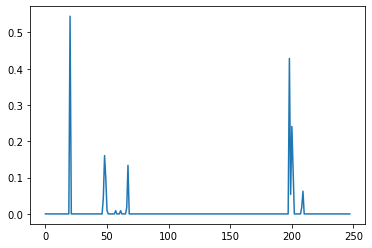

In [758]:
model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

plt.plot(compute_spontaneous_activity(spike_RA.t, duration)/112)

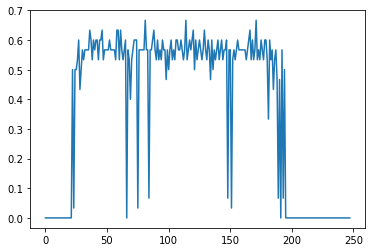

In [759]:
plt.plot(compute_spontaneous_activity(spike_SA2.t, duration)/30)

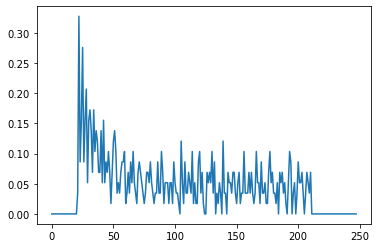

In [760]:
plt.plot(compute_spontaneous_activity(spike_SA1.t, duration)/58)

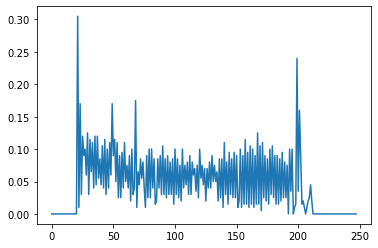

In [761]:
plt.plot(compute_spontaneous_activity(spike_TG.t, duration)/200)

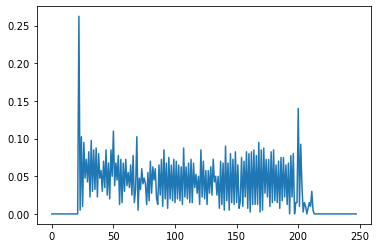

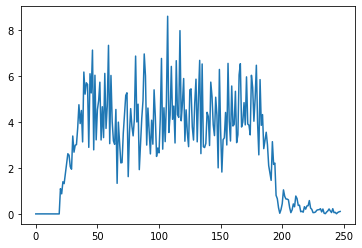

In [762]:
plt.plot(compute_spontaneous_activity(spike_BS.t, duration)/400)
plt.show()
plt.plot(amplitude.values)

In [743]:
len(np.unique(spike_BS.i))

176

### Spikes generation

In [763]:
fav_angles_SA1 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 58) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 30)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented_gauss(180, 0, 45, 112) #define_favorite_angles_gauss(90, 270, 45, 50)

In [764]:
torques, stim_id = load_data('./0_amplitude/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/Scale1/0_amplitude/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')

    np.savetxt('./neural_activity/Scale1/0_amplitude/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_amplitude/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')

In [765]:
torques, stim_id = load_data('./0_direction/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/Scale1/0_direction/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')

    np.savetxt('./neural_activity/Scale1/0_direction/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_direction/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')

WARNING    'i' is an internal variable of group 'synapses_15', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [766]:
torques, stim_id = load_data('./0_distance_to_basis/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')

    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_distance_to_basis/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')

WARNING    'i' is an internal variable of group 'synapses_13', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [767]:
torques, stim_id = load_data('./0_frequency/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/Scale1/0_frequency/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')

    np.savetxt('./neural_activity/Scale1/0_frequency/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_frequency/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')

In [768]:
torques, stim_id = load_data('./0_slope_speed/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS = model_mechano_noise(fav_angles_SA1, fav_angles_SA2, fav_angles_RA, 100, 100, 100)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/Scale1/0_slope_speed/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')

    np.savetxt('./neural_activity/Scale1/0_slope_speed/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/Scale1/0_slope_speed/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')

### TC + CTX

In [17]:
fav_angles_SA1 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 24) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 10)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented_gauss(180, 0, 45, 36) #define_favorite_angles_gauss(90, 270, 45, 50)

In [90]:
torques, stim_id = load_data('./0_slope_speed/Moments')
torques, stim_id = load_data('./0_distance_to_basis/Moments')
torques, stim_id = load_data('./0_amplitude/Moments')

In [91]:
amplitude = compute_amplitude(torques[9][1:])
#amplitude = amplitude/max(amplitude)
amplitude = 10 * amplitude
amplitude = filter_signal_hanning(amplitude, 3)
amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
direction = compute_direction(0, amplitude)

duration = len(amplitude)

amplitude = TimedArray(amplitude, dt = 1 * ms)
amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
direction = TimedArray(direction, dt = 1 * ms)

In [92]:
CTX_eq = '''

gaba2 : 1
ampa2 : 1
taud_g : second
taur_g : second
slope_g : volt
gsyn_g : siemens/meter**2
Esyn_g : volt
taud_a : second
taur_a : second
slope_a : volt
gsyn_a : siemens/meter**2
Esyn_a : volt

Cm = 1*uF/cm**2 : farad/meter**2
gleak : siemens/meter**2
gNa : siemens/meter**2
gK : siemens/meter**2
gM  : siemens/meter**2
Eleak : volt
V_T : volt
tau_max_M : second

random_var : 1
noise_std = 5 * mA/meter**2 : amp/meter**2
noise_mean = 0 * nA/meter**2 : amp/meter**2
Inoise = noise_mean + noise_std * random_var: amp/meter**2

beta_n = 0.50 * exp( -(v-V_T - 10.0*mV)/(40.0*mV))*1/msecond : Hz
alpha_n = -0.0320/mV*(v-V_T-15.0*mV) / (exp( -(v-V_T - 15.0*mV)/(5.0*mV)) - 1) * 1/msecond : Hz
dn/dt = alpha_n * (1-n) - beta_n * n: 1

alpha_m =  -0.32/mV*(v-V_T-13.*mV) / (exp(-(v-V_T-13.*mV)/(4.*mV))-1) * 1/msecond : Hz
beta_m = ( 0.28/mV * ((v-V_T-40.*mV))) / (exp((v-V_T-40.*mV)/(5.*mV))-1 ) * 1/msecond : Hz
dm/dt = alpha_m * (1-m) - beta_m * m : 1

alpha_h = 0.128 * exp(-(v-V_T-17.*mV)/(18.*mV)) * 1/msecond : Hz
beta_h = 4./(1.+exp(-(v-V_T-40.*mV)/(5.*mV))) * 1/msecond : Hz
dh/dt = alpha_h * (1-h) - beta_h * h: 1


p_inf = 1 / (1.+exp(-(v+35.*mV)/(10.*mV))) : 1
tau_p = tau_max_M /( (3.3*exp((v+35.*mV)/(20.*mV)) + exp(-(v+35.*mV)/(20.*mV)))) : second
dp/dt = (p_inf - p)/tau_p : 1

IK    = -gK * n**4 *(v-EK_ctx) : ampere/meter**2
INa   = -gNa*m**3*h*(v-ENa_ctx)   : ampere/meter**2
IM    = -gM *p *(v-EM_ctx)  : ampere/meter**2
Ileak = -gleak*(v-Eleak): ampere/meter**2

dgaba1/dt = -gaba1/taud_g + 1/2 * (1 + (tanh(v/slope_g)))* (1-gaba1)/taur_g : 1 
dampa1/dt = -ampa1/taud_a + 1/2 * (1 + (tanh(v/slope_a)))* (1-ampa1)/taur_a : 1 

Igaba = -gsyn_g * gaba2 * (v-Esyn_g): amp/meter**2
Iampa = -gsyn_a * ampa2 * (v-Esyn_a): amp/meter**2



dv/dt = (IK + INa + IM + Ileak + Igaba + Iampa + Inoise)/Cm  : volt
'''

VPM = '''
dv/dt = (Iapp - INa - IK - IT - Ih - ILeak - IKleak)/Cm : volt

INa = gNa_vpm * m**3 * h * (v - ENa_vpm) : amp/meter**2
IK = gK_vpm * n**4 * (v - EK_vpm) : amp/meter**2
ILeak = gleak_vpm * (v - Eleak_vpm) : amp/meter**2
IKleak = gKleak_vpm * (v - EKleak_vpm) : amp/meter**2
IT = gCa_vpm * mT_inf**2 * hT * (v - ECa) : amp/meter**2
Ih = gh_vpm * (o1 + 2*(1 - c1 - o1)) * (v - Eh_vpm) : amp/meter**2

dm/dt = alpha_m * (1 - m) - beta_m * m : 1
dh/dt = alpha_h * (1 - h) - beta_h * h : 1
dn/dt = alpha_n * (1 - n) - beta_n * n : 1
dhT/dt = (hT_inf - hT) / tau_hT : 1

ECa = ((GasConst * 309.15*kelvin) / (2 * FaradConst)) * log(2 / CaBuffer) : volt
CaBufferTemp = ((-10 * IT/(amp/meter**2)) / (2 * FaradConst / (coulomb/mole))) : 1
dCaBuffer/dt = (int(CaBufferTemp > 0) * CaBufferTemp + (0.00024-CaBuffer)/5 ) / ms : 1 

do1/dt = (0.001 * (1 - c1 - o1) - 0.001 * ( (1-p0) / 0.01)) * o1 / ms : 1
dp0/dt = (0.0004 *  (1 - p0) - 0.0004 * ((CaBuffer / 0.002)**4) * p0) / ms : 1
dc1/dt = beta * o1 - alpha * c1 : 1

alpha_m = ((0.32 * (13 - (v/mV + 35))) / (exp((13 - (v/mV + 35))/4) - 1)) / ms : Hz
beta_m = ((0.28 * ((v/mV + 35) - 40)) / (exp(((v/mV + 35) - 40)/5) - 1)) / ms : Hz
alpha_h = (0.128 * exp((17 - v/mV - 35)/18)) / ms : Hz
beta_h = (4 / (1 + exp((40 - v/mV - 35)/5))) / ms : Hz

alpha_n = ((0.032 * (15 - (v/mV + 25))) / (exp((15 - (v/mV + 25))/5) - 1)) / ms : Hz
beta_n = (0.5 * exp((10 - (v/mV + 25)) / 40)) / ms : Hz

alpha = h_inf / tau_s : Hz
beta = (1 - h_inf) / tau_s : Hz

mT_inf = 1 / (1 + exp((-((v/mV + 2) + 57)) / 6.2)) : 1
hT_inf = 1 / (1 + exp(((v/mV + 2) + 81)/4)) : 1
tau_hT = (( 30.8 + (211.4 + exp(((v/mV+2) + 113.2)/5))/(1+exp(((v/mV + 2)+84)/3.2))) / 3.73) * ms : second

h_inf =  1 / (1 + exp( (v/mV + 75)/5.5 )) : 1
tau_s = (20 + 1000 / (exp( (v/mV + 71.5)/14.2 ) + exp( (-(v/mV + 89))/11.6))) * ms: second

Cm = 1*uF/cm**2 : farad/meter**2
Iapp : amp/meter**2

taud : second
taur : second
slope : volt

ds1/dt = (-s1/taud + 1/2 * (1 + (tanh(v/slope)))* (1-s1)/taur) : 1 
'''

#Replace 200 by noiseSA1 or noiseSA2

WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'ampa2_post = 8.1 * ampa1_pre'
 [brian2.codegen.generators.base]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'gaba2_post = 17.0 * gaba1_pre'
 [brian2.codegen.generators.base]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'gaba2_post = 15.0 * gaba1_pre'
 [brian2.codegen.generators.base]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the orde

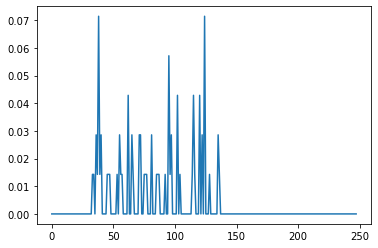

In [102]:
model, statemon_L4E, statemon_TC, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)
#run_model(direction, amplitude, amplitude_ON_OFF, I, model, duration)

plt.plot(compute_spontaneous_activity(spike_TC.t, duration)/70)

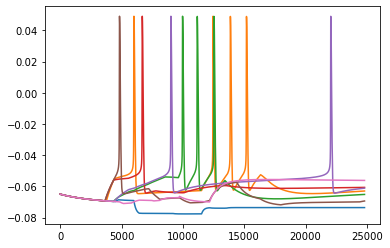

In [103]:
plt.plot(statemon_L4E.v[0])
plt.plot(statemon_L4E.v[1])
plt.plot(statemon_L4E.v[2])
plt.plot(statemon_L4E.v[3])
plt.plot(statemon_L4E.v[4])
plt.plot(statemon_L4E.v[5])
plt.plot(statemon_L4E.v[20])
#plt.plot(statemon_L4E.v[50])
#plt.plot(statemon_L4E.v[70])

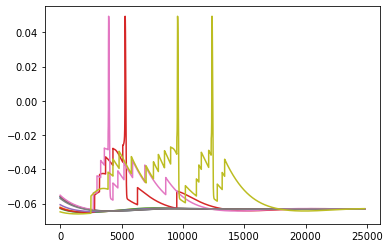

In [104]:
plt.plot(statemon_TC.v[0])
plt.plot(statemon_TC.v[1])
plt.plot(statemon_TC.v[2])
plt.plot(statemon_TC.v[3])
plt.plot(statemon_TC.v[4])
plt.plot(statemon_TC.v[5])
plt.plot(statemon_TC.v[20])
plt.plot(statemon_TC.v[50])
plt.plot(statemon_TC.v[69])

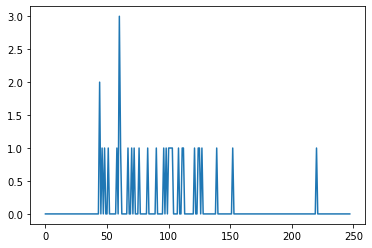

In [ ]:
plt.plot(compute_spontaneous_activity(spike_L4I.t, duration))
#plt.plot(statemon.v)

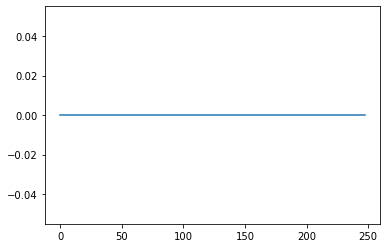

In [106]:
plt.plot(compute_spontaneous_activity(spike_L3E.t, duration))
#plt.plot(statemon.v)

In [834]:
fav_angles_SA1 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 24) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented_gauss(180, 0, 45, 10)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented_gauss(180, 0, 45, 36) #define_favorite_angles_gauss(90, 270, 45, 50)

In [835]:
torques, stim_id = load_data('./0_amplitude/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/ScaleTH/0_amplitude/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/TH/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/ScaleTH/0_amplitude/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/TH/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_amplitude/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

WARNING    'i' is an internal variable of group 'synapses_71', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_72', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_73', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_74', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'Eleak' is an internal variable of group 'neurongroup_21', but also exists in the run namespace with the value -70. * mvolt. The internal variabl

In [ ]:
torques, stim_id = load_data('./0_direction/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/ScaleTH/0_direction/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/TH/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/ScaleTH/0_direction/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/TH/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_direction/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

WARNING    'i' is an internal variable of group 'synapses_15', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [ ]:
torques, stim_id = load_data('./0_distance_to_basis/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/TH/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/TH/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_distance_to_basis/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

WARNING    'i' is an internal variable of group 'synapses_13', but also exists in the run namespace with the value 19. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [ ]:
torques, stim_id = load_data('./0_frequency/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/ScaleTH/0_frequency/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/TH/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/ScaleTH/0_frequency/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/TH/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_frequency/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

In [ ]:
torques, stim_id = load_data('./0_slope_speed/Moments')
for idx, stimulus in enumerate(stim_id):
    amplitude = compute_amplitude(torques[idx][1:])
    #amplitude = amplitude/max(amplitude)
    amplitude = 10 * amplitude
    amplitude = filter_signal_hanning(amplitude, 3)
    amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
    direction = compute_direction(0, amplitude)

    duration = len(amplitude)

    amplitude = TimedArray(amplitude, dt = 1 * ms)
    amplitude_ON_OFF = TimedArray(amplitude_ON_OFF, dt = 1 * ms)
    direction = TimedArray(direction, dt = 1 * ms)

    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I  = model_mechano_TH_CTX(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model_TC_CTX(direction, amplitude, amplitude_ON_OFF, I, model, duration)

    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/TH/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/TH/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/ScaleTH/0_slope_speed/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

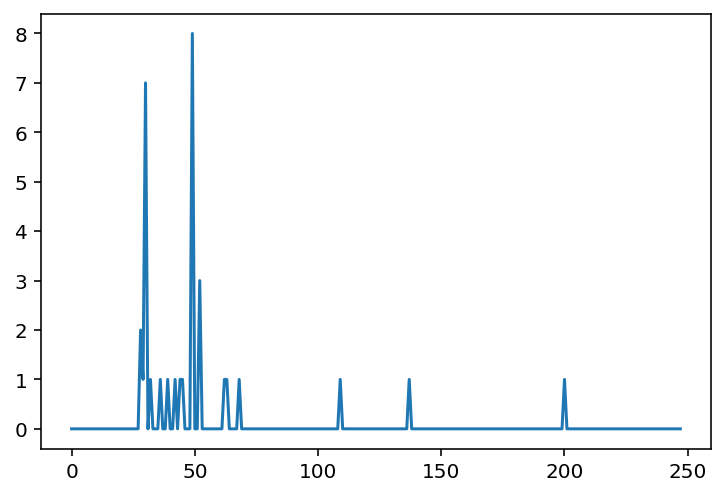

In [964]:
plt.plot(compute_spontaneous_activity(spike_TC.t, duration))

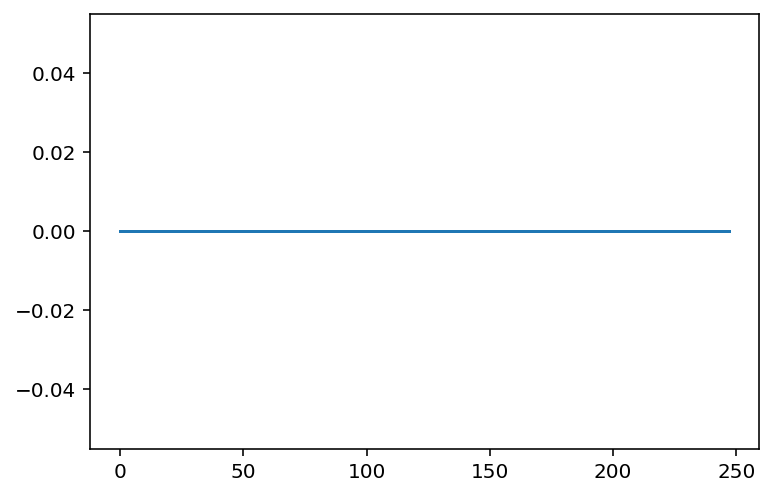

In [963]:
plt.plot(compute_spontaneous_activity(spike_L4E.t, duration)/112)